In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [80]:
data = pd.read_csv(r'Coffe_sales.csv')
data.head()

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000
2,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000
3,13,card,28.9,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000
4,13,card,38.7,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000


In [81]:
data['Date'] = pd.to_datetime(data['Date'].astype(str))

In [82]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   hour_of_day  3547 non-null   int64         
 1   cash_type    3547 non-null   object        
 2   money        3547 non-null   float64       
 3   coffee_name  3547 non-null   object        
 4   Time_of_Day  3547 non-null   object        
 5   Weekday      3547 non-null   object        
 6   Month_name   3547 non-null   object        
 7   Weekdaysort  3547 non-null   int64         
 8   Monthsort    3547 non-null   int64         
 9   Date         3547 non-null   datetime64[ns]
 10  Time         3547 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(6)
memory usage: 304.9+ KB


# Section 1: Sales Performance Analysis
# monthly revenue summary table
- Calculate total revenue per month across the entire dataset. Identify the highest and lowest revenue months and compute month-over-month percentage change.


In [83]:
data.isna().sum()

hour_of_day    0
cash_type      0
money          0
coffee_name    0
Time_of_Day    0
Weekday        0
Month_name     0
Weekdaysort    0
Monthsort      0
Date           0
Time           0
dtype: int64

In [84]:
print('Total sales: ', data['money'].sum())

Total sales:  112245.57999999999


In [85]:
data['year'] = data['Date'].dt.year

In [86]:
data['Year_month'] = data['Month_name'].astype(str)+', ' +data['year'].astype(str)
data

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time,year,Year_month
0,10,card,38.70,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000,2024,"Mar, 2024"
1,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000,2024,"Mar, 2024"
2,12,card,38.70,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:20:18.089000,2024,"Mar, 2024"
3,13,card,28.90,Americano,Afternoon,Fri,Mar,5,3,2024-03-01,13:46:33.006000,2024,"Mar, 2024"
4,13,card,38.70,Latte,Afternoon,Fri,Mar,5,3,2024-03-01,13:48:14.626000,2024,"Mar, 2024"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3542,10,card,35.76,Cappuccino,Morning,Sun,Mar,7,3,2025-03-23,10:34:54.894000,2025,"Mar, 2025"
3543,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:43:37.362000,2025,"Mar, 2025"
3544,14,card,35.76,Cocoa,Afternoon,Sun,Mar,7,3,2025-03-23,14:44:16.864000,2025,"Mar, 2025"
3545,15,card,25.96,Americano,Afternoon,Sun,Mar,7,3,2025-03-23,15:47:28.723000,2025,"Mar, 2025"


In [87]:
monthly_revenue = data.groupby(['year', 'Monthsort', 'Month_name', 'Year_month'])['money'].sum().reset_index(name='revenue').sort_values('year')
monthly_revenue

,year,Monthsort,Month_name,Year_month,revenue
0,2024,3,Mar,"Mar, 2024",5905.20
1,2024,4,Apr,"Apr, 2024",5719.56
2,2024,5,May,"May, 2024",8164.42
3,2024,6,Jun,"Jun, 2024",7617.76
4,2024,7,Jul,"Jul, 2024",6915.94
5,2024,8,Aug,"Aug, 2024",7613.84
6,2024,9,Sep,"Sep, 2024",9988.64
7,2024,10,Oct,"Oct, 2024",13891.16
8,2024,11,Nov,"Nov, 2024",8590.54
9,2024,12,Dec,"Dec, 2024",8237.74


In [88]:
# Highest revenue Month
heighest_month = monthly_revenue.loc[monthly_revenue['revenue'].idxmax()]
heighest_month

year               2024
Monthsort            10
Month_name          Oct
Year_month    Oct, 2024
revenue        13891.16
Name: 7, dtype: object

In [89]:
lowest_month = monthly_revenue.loc[monthly_revenue['revenue'].idxmin()]
lowest_month

year               2024
Monthsort             4
Month_name          Apr
Year_month    Apr, 2024
revenue         5719.56
Name: 1, dtype: object

In [90]:
# Month over Month percentage change
monthly_revenue['MoM_%_change'] = monthly_revenue['revenue'].pct_change() * 100
monthly_revenue

,year,Monthsort,Month_name,Year_month,revenue,MoM_%_change
0,2024,3,Mar,"Mar, 2024",5905.20,NaN
1,2024,4,Apr,"Apr, 2024",5719.56,-3.143670
2,2024,5,May,"May, 2024",8164.42,42.745596
3,2024,6,Jun,"Jun, 2024",7617.76,-6.695638
4,2024,7,Jul,"Jul, 2024",6915.94,-9.212944
5,2024,8,Aug,"Aug, 2024",7613.84,10.091181
6,2024,9,Sep,"Sep, 2024",9988.64,31.190569
7,2024,10,Oct,"Oct, 2024",13891.16,39.069583
8,2024,11,Nov,"Nov, 2024",8590.54,-38.158224
9,2024,12,Dec,"Dec, 2024",8237.74,-4.106843


/tmp/ipykernel_5151/744250095.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x = 'Year_month', y = 'revenue', ci = None, marker = 'D', data = monthly_revenue, label = 'Monthly Revenue')


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'Mar, 2024'),
  Text(1, 0, 'Apr, 2024'),
  Text(2, 0, 'May, 2024'),
  Text(3, 0, 'Jun, 2024'),
  Text(4, 0, 'Jul, 2024'),
  Text(5, 0, 'Aug, 2024'),
  Text(6, 0, 'Sep, 2024'),
  Text(7, 0, 'Oct, 2024'),
  Text(8, 0, 'Nov, 2024'),
  Text(9, 0, 'Dec, 2024'),
  Text(10, 0, 'Jan, 2025'),
  Text(11, 0, 'Feb, 2025'),
  Text(12, 0, 'Mar, 2025')])

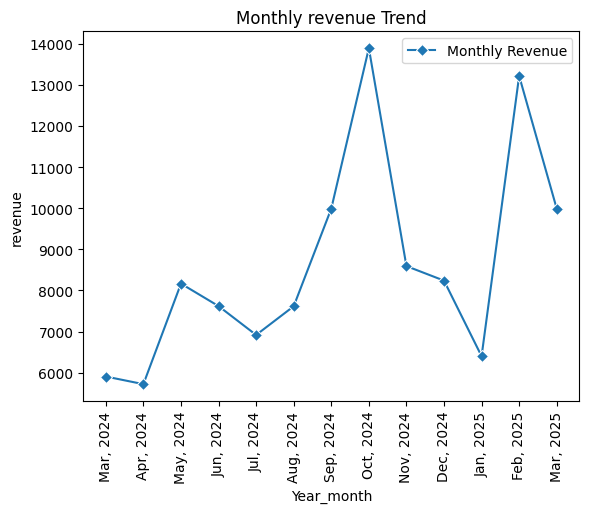

In [91]:
plt.title('Monthly revenue Trend')
sns.lineplot(x = 'Year_month', y = 'revenue', ci = None, marker = 'D', data = monthly_revenue, label = 'Monthly Revenue')
plt.xticks(rotation=90)

<Axes: title={'center': 'Month over Month Percentage Change in Revenue'}, xlabel='MoM_%_change', ylabel='Year_month'>

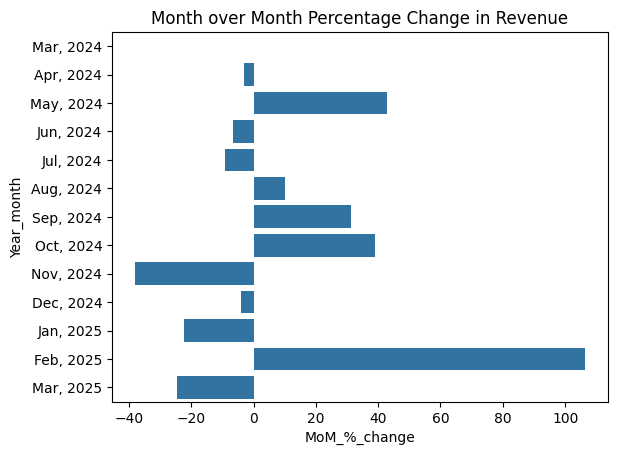

In [92]:
plt.title("Month over Month Percentage Change in Revenue")
sns.barplot(x = 'MoM_%_change', y = 'Year_month', data = monthly_revenue)

# Top-Selling Drinks by volume and revenue

In [93]:
drink_transactions = data.groupby('coffee_name')['money'].sum().sort_values().reset_index()
drink_revenue = data['coffee_name'].value_counts().reset_index(name = 'transaction')
    #transactions = data.groupby('coffee_name')['money'].count()
drink_tran_rev = drink_transactions.merge(drink_revenue, on = 'coffee_name')

In [94]:
drink_tran_rev

,coffee_name,money,transaction
0,Espresso,2690.28,129
1,Cortado,7384.86,287
2,Cocoa,8521.16,239
3,Hot Chocolate,9933.46,276
4,Americano,14650.26,564
5,Cappuccino,17439.14,486
6,Americano with Milk,24751.12,809
7,Latte,26875.30,757


In [95]:
# Ranking of drinks from lowest to highest revenue with its transaction
drink_tran_rev['rank'] = range(1, len(drink_tran_rev)+1)
drink_tran_rev

,coffee_name,money,transaction,rank
0,Espresso,2690.28,129,1
1,Cortado,7384.86,287,2
2,Cocoa,8521.16,239,3
3,Hot Chocolate,9933.46,276,4
4,Americano,14650.26,564,5
5,Cappuccino,17439.14,486,6
6,Americano with Milk,24751.12,809,7
7,Latte,26875.30,757,8


# Average transaction value per drink

In [96]:
avg_tran_val = data.groupby('coffee_name')['money'].mean().reset_index(name = 'avg_order_value')
avg_tran_val.sort_values('avg_order_value')

,coffee_name,avg_order_value
5,Espresso,20.854884
4,Cortado,25.731220
0,Americano,25.975638
1,Americano with Milk,30.594710
7,Latte,35.502378
3,Cocoa,35.653389
2,Cappuccino,35.883004
6,Hot Chocolate,35.990797


In [97]:
highest_avg = avg_tran_val.loc[avg_tran_val['avg_order_value'].idxmax()]
lowest_avg = avg_tran_val.loc[avg_tran_val['avg_order_value'].idxmin()]
print(f'Heighest drink revenue per transection on average: {highest_avg}')
print(f'Lowest drink revenue per transection on average: {lowest_avg}')

Heighest drink revenue per transection on average: coffee_name        Hot Chocolate
avg_order_value        35.990797
Name: 6, dtype: object
Lowest drink revenue per transection on average: coffee_name         Espresso
avg_order_value    20.854884
Name: 5, dtype: object


In [98]:
highest_avg = avg_tran_val.iloc[0]
lowest_avg = avg_tran_val.iloc[-1]

print("Highest Average Order Value:")
print(highest_avg)

print("\nLowest Average Order Value:")
print(lowest_avg)

Highest Average Order Value:
coffee_name        Americano
avg_order_value    25.975638
Name: 0, dtype: object

Lowest Average Order Value:
coffee_name            Latte
avg_order_value    35.502378
Name: 7, dtype: object


# Section 3: Time and Demand patterns
# Peak sales hour identification

In [99]:
hourly_trans = data['hour_of_day'].value_counts().sort_index().reset_index()
hourly_trans.columns= ['hour_of_day', 'transaction']
hourly_trans

,hour_of_day,transaction
0,6,5
1,7,88
2,8,235
3,9,242
4,10,328
5,11,283
6,12,241
7,13,225
8,14,225
9,15,236


In [100]:
# Identify top 3 rush hours
top_3_hours=hourly_trans.nlargest(3, 'transaction')
top_3_hours

,hour_of_day,transaction
4,10,328
5,11,283
10,16,278


/tmp/ipykernel_5151/789758685.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'hour_of_day', y = 'transaction', data=hourly_trans, palette = colors)


<Axes: title={'center': 'Hourly order Volume and highlighted Top 3'}, xlabel='hour_of_day', ylabel='transaction'>

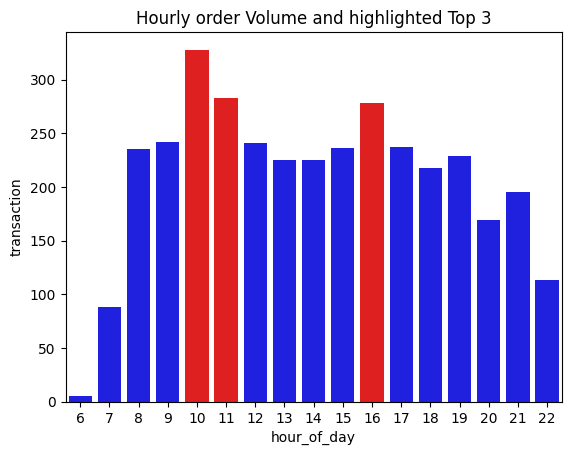

In [101]:
# Plot hourly transaction volume
colors = ['red' if hour in top_3_hours['hour_of_day'].values else 'blue' for hour in hourly_trans['hour_of_day']]
plt.title("Hourly order Volume and highlighted Top 3")
sns.barplot(x = 'hour_of_day', y = 'transaction', data=hourly_trans, palette = colors)

# Day of week revenue pattern

In [102]:
# Aggregate total sales and transaction count by weekday
weekday_summery = data.groupby(['Weekdaysort', 'Weekday']).agg(total_sales = ('money', 'sum'), total_tansaction = ('money', 'count')).reset_index()
weekday_summery

,Weekdaysort,Weekday,total_sales,total_tansaction
0,1,Mon,17363.10,544
1,2,Tue,18168.38,572
2,3,Wed,15750.46,500
3,4,Thu,16091.40,510
4,5,Fri,16802.66,532
5,6,Sat,14733.52,470
6,7,Sun,13336.06,419


In [103]:
# Identify busiest and slowest day based on transactions
busiest_day = weekday_summery.loc[weekday_summery['total_tansaction'].idxmax()]
busiest_day
slowest_day = weekday_summery.loc[weekday_summery['total_tansaction'].idxmin()]
print('Busiest day:\n ', busiest_day)
print('Slowest day:\n ', slowest_day)

Busiest day:
  Weekdaysort                2
Weekday                  Tue
total_sales         18168.38
total_tansaction         572
Name: 1, dtype: object
Slowest day:
  Weekdaysort                7
Weekday                  Sun
total_sales         13336.06
total_tansaction         419
Name: 6, dtype: object


<Axes: title={'center': 'Weekday sales in number of transactions.'}, xlabel='Weekday', ylabel='total_tansaction'>

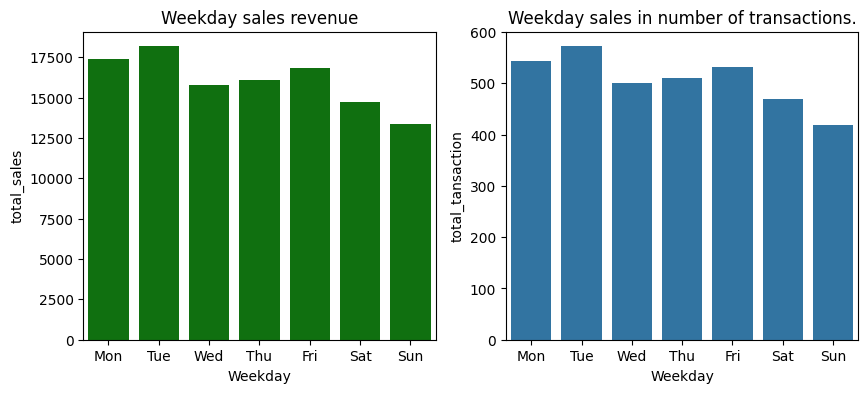

In [104]:
fig, axes = plt.subplots(1, 2, figsize = (10, 4))
axes[0].set_title("Weekday sales revenue")
axes[1].set_title("Weekday sales in number of transactions.")
sns.barplot(x = 'Weekday', y = 'total_sales', data=weekday_summery, ax=axes[0], color = 'green')
sns.barplot(x = 'Weekday', y = 'total_tansaction', data=weekday_summery, ax=axes[1])

# Morning Vs Afternoon Vs Night revenue

In [105]:
# Compare total sales and transaction count across Morning, Afternoon, and Night
segment_summery = data.groupby('Time_of_Day').agg(total_sales = ('money', 'sum'), total_transactions = ('money', 'count')).reset_index()
segment_summery

,Time_of_Day,total_sales,total_transactions
0,Afternoon,38130.04,1205
1,Morning,35929.20,1181
2,Night,38186.34,1161


In [106]:
# Popular drink preferences by time segment
drink_preferences = data.groupby(['Time_of_Day', 'coffee_name']).size().reset_index(name = 'transaction')
drink_preferences= drink_preferences.sort_values(['Time_of_Day', 'transaction'], ascending=[True, False])

In [107]:
drink_preferences

,Time_of_Day,coffee_name,transaction
7,Afternoon,Latte,270
1,Afternoon,Americano with Milk,239
0,Afternoon,Americano,233
2,Afternoon,Cappuccino,164
4,Afternoon,Cortado,88
6,Afternoon,Hot Chocolate,80
3,Afternoon,Cocoa,75
5,Afternoon,Espresso,56
9,Morning,Americano with Milk,331
8,Morning,Americano,219


In [108]:
# Top drink in each time segment
top_drink = drink_preferences.groupby('Time_of_Day').first().reset_index()
top_drink

,Time_of_Day,coffee_name,transaction
0,Afternoon,Latte,270
1,Morning,Americano with Milk,331
2,Night,Latte,272


In [109]:
timesegment_summery = data.groupby('hour_of_day').agg(transaction = ('money', 'sum'))

<Axes: xlabel='hour_of_day', ylabel='transaction'>

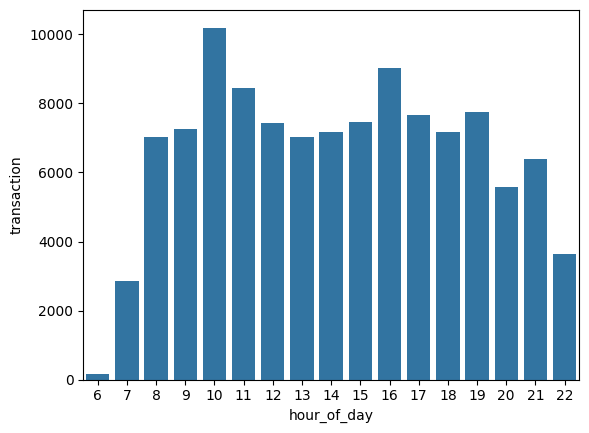

In [110]:
sns.barplot(x = 'hour_of_day', y = 'transaction', data=timesegment_summery)

# Section 3: Product and Pricing insights
# Revenue contribution (%) per drink    

In [111]:
# Calculate revenue share percentage for each drink
drink_rev_share = data.groupby('coffee_name')['money'].sum().reset_index(name = 'transaction')
drink_rev_share

,coffee_name,transaction
0,Americano,14650.26
1,Americano with Milk,24751.12
2,Cappuccino,17439.14
3,Cocoa,8521.16
4,Cortado,7384.86
5,Espresso,2690.28
6,Hot Chocolate,9933.46
7,Latte,26875.30


In [112]:
total_rev = drink_rev_share['transaction'].sum()
total_rev

np.float64(112245.57999999999)

In [113]:
drink_rev_share['Revenue_%_share'] = drink_rev_share['transaction']/ total_rev *100
drink_rev_share

,coffee_name,transaction,Revenue_%_share
0,Americano,14650.26,13.051971
1,Americano with Milk,24751.12,22.050864
2,Cappuccino,17439.14,15.536594
3,Cocoa,8521.16,7.591533
4,Cortado,7384.86,6.579199
5,Espresso,2690.28,2.396780
6,Hot Chocolate,9933.46,8.849756
7,Latte,26875.30,23.943304


([<matplotlib.patches.Wedge at 0x75e3f8f420d0>,
 [Text(1.0088154739148631, 0.43851036429020745, 'Americano'),
  Text(0.06372972363328597, 1.0981523220052969, 'Americano with Milk'),
  Text(-0.9914848720120581, 0.47640082763491587, 'Cappuccino'),
  Text(-1.057563874071041, -0.3025866029087404, 'Cocoa'),
  Text(-0.8241817081396311, -0.7285084158525832, 'Cortado'),
  Text(-0.5889104804818924, -0.9290772013016931, 'Espresso'),
  Text(-0.23105852577892808, -1.0754589521059688, 'Hot Chocolate'),
  Text(0.803205563006791, -0.7515722344225763, 'Latte')],
 [Text(0.5502629857717435, 0.23918747143102223, '13.1%'),
  Text(0.034761667436337795, 0.5989921756392528, '22.1%'),
  Text(-0.5408099301883953, 0.25985499689177227, '15.5%'),
  Text(-0.5768530222205677, -0.165047237950222, '7.6%'),
  Text(-0.4495536589852533, -0.39736822682868167, '6.6%'),
  Text(-0.32122389844466853, -0.5067693825281961, '2.4%'),
  Text(-0.12603192315214257, -0.5866139738759829, '8.8%'),
  Text(0.4381121252764314, -0.4099484

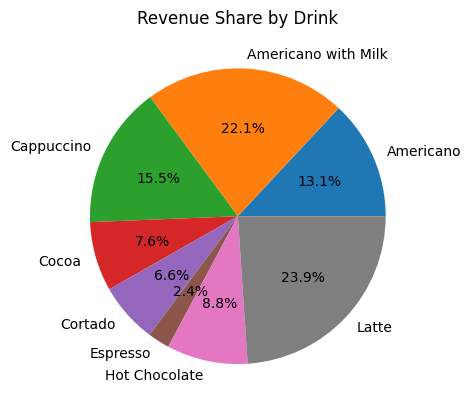

In [114]:
plt.title('Revenue Share by Drink')
plt.pie(drink_rev_share['Revenue_%_share'], labels = drink_rev_share['coffee_name'], autopct = '%1.1f%%')

In [115]:
# Flag drinks contributing less than 5%
low_contributers = drink_rev_share[drink_rev_share['Revenue_%_share'] < 5]
low_contributers

,coffee_name,transaction,Revenue_%_share
5,Espresso,2690.28,2.39678


# Price consistency check    

In [116]:
data['money'].unique()

array([38.7 , 28.9 , 33.8 , 24.  , 32.82, 37.72, 27.92, 23.02, 18.12,
       35.76, 30.86, 25.96, 21.06])

In [117]:
# unique prices each coffee has
price_variation = data.groupby('coffee_name')['money'].nunique().reset_index()
price_variation.columns = ['coffee_name', 'unique_price_count']
price_variation

,coffee_name,unique_price_count
0,Americano,4
1,Americano with Milk,4
2,Cappuccino,4
3,Cocoa,4
4,Cortado,4
5,Espresso,4
6,Hot Chocolate,4
7,Latte,4


In [118]:
inconsistant_price = price_variation[ 'unique_price_count'] > 1
inconsistant_price

0    True
1    True
2    True
3    True
4    True
5    True
6    True
7    True
Name: unique_price_count, dtype: bool

In [119]:
data.groupby('coffee_name')['money'].agg(['min', 'max', 'nunique'])


,min,max,nunique
coffee_name,,,
Americano,23.02,28.9,4
Americano with Milk,27.92,33.8,4
Cappuccino,32.82,38.7,4
Cocoa,32.82,38.7,4
Cortado,23.02,28.9,4
Espresso,18.12,24.0,4
Hot Chocolate,32.82,38.7,4
Latte,32.82,38.7,4


# Section 4: Business Insights & Recommendations
# Seasonal revenue trend report  

In [120]:
season_map = {
    'Jan': 'Winter',
    'Feb': 'Winter',
    'Mar': 'Spring',
    'Apr': 'Spring',
    'May': 'Spring',
    'Jun': 'Summer',
    'Jul': 'Summer',
    'Aug': 'Summer',
    'Sept': 'Autumn',
    'Oct': 'Autumn',
    'Nov': 'Autumn',
    'Dec': 'Winter'
}
data['season'] = data['Month_name'].map(season_map)
data.head(2)

,hour_of_day,cash_type,money,coffee_name,Time_of_Day,Weekday,Month_name,Weekdaysort,Monthsort,Date,Time,year,Year_month,season
0,10,card,38.7,Latte,Morning,Fri,Mar,5,3,2024-03-01,10:15:50.520000,2024,"Mar, 2024",Spring
1,12,card,38.7,Hot Chocolate,Afternoon,Fri,Mar,5,3,2024-03-01,12:19:22.539000,2024,"Mar, 2024",Spring


In [121]:
seasonal_summery = data.groupby(['season']).agg(revenue = ('money', 'sum'))
seasonal_summery=seasonal_summery.sort_values(['season'],ascending = True)
seasonal_summery

,revenue
season,
Autumn,22481.70
Spring,29775.62
Summer,22147.54
Winter,27852.08


/tmp/ipykernel_5151/1715701869.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x = 'season', y='revenue', ci = None, marker = 'D', data = seasonal_summery)


<Axes: xlabel='season', ylabel='revenue'>

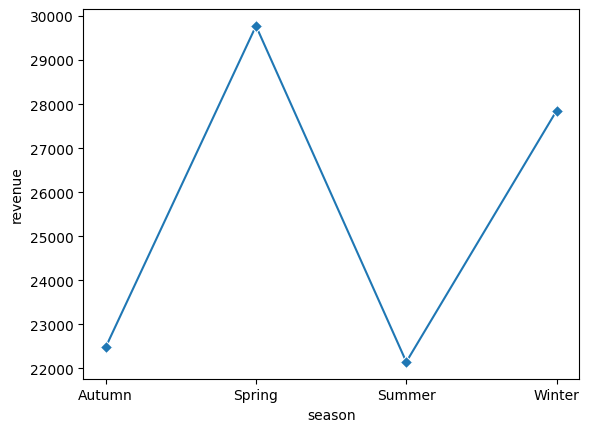

In [122]:
sns.lineplot(x = 'season', y='revenue', ci = None, marker = 'D', data = seasonal_summery)

In [123]:
# top season 
seasonal_summery.idxmax()

revenue    Spring
dtype: object

# Low-performer drinks action plan    


In [124]:
revenue_rank = data.groupby('coffee_name').agg(revenue= ('money', 'sum'), transaction=('money', 'count')).sort_values('revenue')
revenue_rank.reset_index()

,coffee_name,revenue,transaction
0,Espresso,2690.28,129
1,Cortado,7384.86,287
2,Cocoa,8521.16,239
3,Hot Chocolate,9933.46,276
4,Americano,14650.26,564
5,Cappuccino,17439.14,486
6,Americano with Milk,24751.12,809
7,Latte,26875.30,757


In [125]:
txn_rank = data['coffee_name'].value_counts().sort_values()
bottom_revenue = revenue_rank.head(2)
bottom_txn = txn_rank.head(2)

bottom_revenue, bottom_txn

(             revenue  transaction
 coffee_name                      
 Espresso     2690.28          129
 Cortado      7384.86          287,
 coffee_name
 Espresso    129
 Cocoa       239
 Name: count, dtype: int64)

In [126]:
data[data['coffee_name'].isin(['Espresso','Cocoa'])] \
.groupby('coffee_name')['money'].agg(['min','max','mean','count'])

,min,max,mean,count
coffee_name,,,,
Cocoa,32.82,38.7,35.653389,239
Espresso,18.12,24.0,20.854884,129


In [127]:
# Check time-of-day demand
data[data['coffee_name'].isin(['Espresso','Cocoa'])] \
.groupby(['coffee_name','Time_of_Day'])['money'].count()


coffee_name  Time_of_Day
Cocoa        Afternoon       75
             Morning         58
             Night          106
Espresso     Afternoon       56
             Morning         44
             Night           29
Name: money, dtype: int64

In [128]:
# Seasonal behavior
data[data['coffee_name'].isin(['Espresso','Cocoa'])] \
.groupby(['coffee_name','season'])['money'].count()

coffee_name  season
Cocoa        Autumn    67
             Spring    48
             Summer    24
             Winter    91
Espresso     Autumn    15
             Spring    30
             Summer    38
             Winter    34
Name: money, dtype: int64

# One-page executive summary dashboard    

# Section 6   Drink × Time-of-Day Affinity
# Which drink dominates each time slot?    


In [129]:
coffee_time_crosstab = pd.crosstab(
    data['coffee_name'],
    data['Time_of_Day']
)
coffee_time_crosstab

Time_of_Day,Afternoon,Morning,Night
coffee_name,,,
Americano,233,219,112
Americano with Milk,239,331,239
Cappuccino,164,122,200
Cocoa,75,58,106
Cortado,88,143,56
Espresso,56,44,29
Hot Chocolate,80,49,147
Latte,270,215,272


In [130]:
# Morning Top Drink
top_drink_morning = coffee_time_crosstab['Morning'].idxmax()
top_drink_evening = coffee_time_crosstab['Afternoon'].idxmax()
top_drink_night = coffee_time_crosstab['Night'].idxmax()
print("Morning Top Drink:", top_drink_morning)
print("Afternoon Top Drink:", top_drink_evening)
print("Night Top Drink:", top_drink_night)

Morning Top Drink: Americano with Milk
Afternoon Top Drink: Latte
Night Top Drink: Latte


# Section 7   Daily Sales Volatility
# Identify unusually high and low sales days    


In [131]:
daily_trans = data.groupby('Date').size().reset_index(name = 'transactions')
daily_trans

,Date,transactions
0,2024-03-01,11
1,2024-03-02,6
2,2024-03-03,9
3,2024-03-04,4
4,2024-03-05,9
...,...,...
376,2025-03-19,21
377,2025-03-20,20
378,2025-03-21,20
379,2025-03-22,12


In [132]:
st = daily_trans['transactions'].std()
mn = daily_trans['transactions'].mean()
lowerbound = mn - 1.5 * st
upperbound = mn + 1.5 * st
print(f'Lower bound of transaction: {lowerbound}')
print(f'Upper bound of transaction: {upperbound}')

Lower bound of transaction: 1.48309145147096
Upper bound of transaction: 17.136331120707517


In [133]:
c1 = daily_trans['transactions']< lowerbound
c2 = daily_trans['transactions']> upperbound
outliers = daily_trans[c1 | c2]
outliers

,Date,transactions
16,2024-03-17,1
23,2024-03-24,1
30,2024-03-31,1
57,2024-04-27,1
65,2024-05-08,1
70,2024-05-13,1
133,2024-07-15,1
135,2024-07-17,1
148,2024-07-30,24
149,2024-07-31,22


In [134]:
outliers['outlier_type'] = outliers['transactions'].apply(lambda x: 'Spike' if x > upperbound else 'Dip')

outliers

/tmp/ipykernel_5151/112739551.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers['outlier_type'] = outliers['transactions'].apply(lambda x: 'Spike' if x > upperbound else 'Dip')


,Date,transactions,outlier_type
16,2024-03-17,1,Dip
23,2024-03-24,1,Dip
30,2024-03-31,1,Dip
57,2024-04-27,1,Dip
65,2024-05-08,1,Dip
70,2024-05-13,1,Dip
133,2024-07-15,1,Dip
135,2024-07-17,1,Dip
148,2024-07-30,24,Spike
149,2024-07-31,22,Spike


# Section 8   Pricing Tier Analysis
# Group drinks into price tiers and compare demand  

In [135]:
bins = [0, 27, 35, 45]
labels = ['Low', 'Mid', 'Premium']

In [136]:
data['Price_tier'] = pd.cut( data['money'], bins=bins, labels = labels)
data[['money', 'Price_tier']].head()

,money,Price_tier
0,38.7,Premium
1,38.7,Premium
2,38.7,Premium
3,28.9,Mid
4,38.7,Premium


In [137]:
tier_revenue = data.groupby('Price_tier').agg(transactions = ('money', 'count'), revenue = ('money', 'sum'), avg_price = ('money', 'mean'))
tier_revenue

/tmp/ipykernel_5151/2345096511.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_revenue = data.groupby('Price_tier').agg(transactions = ('money', 'count'), revenue = ('money', 'sum'), avg_price = ('money', 'mean'))


,transactions,revenue,avg_price
Price_tier,,,
Low,775,18910.66,24.400852
Mid,1357,41823.12,30.820280
Premium,1415,51511.80,36.404099


# Section 9   Year-on-Year Growth Analysis
# Is the business growing? A year-on-year comparison  

In [138]:
monthly_revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          13 non-null     int32  
 1   Monthsort     13 non-null     int64  
 2   Month_name    13 non-null     object 
 3   Year_month    13 non-null     object 
 4   revenue       13 non-null     float64
 5   MoM_%_change  12 non-null     float64
dtypes: float64(2), int32(1), int64(1), object(2)
memory usage: 704.0+ bytes


In [150]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3547 entries, 0 to 3546
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   hour_of_day  3547 non-null   int64         
 1   cash_type    3547 non-null   object        
 2   money        3547 non-null   float64       
 3   coffee_name  3547 non-null   object        
 4   Time_of_Day  3547 non-null   object        
 5   Weekday      3547 non-null   object        
 6   Month_name   3547 non-null   object        
 7   Weekdaysort  3547 non-null   int64         
 8   Monthsort    3547 non-null   int64         
 9   Date         3547 non-null   datetime64[ns]
 10  Time         3547 non-null   object        
 11  year         3547 non-null   int32         
 12  Year_month   3547 non-null   object        
 13  season       3203 non-null   object        
 14  Price_tier   3547 non-null   category      
dtypes: category(1), datetime64[ns](1), float64(1), int32(1)

In [154]:
data_count = data.groupby(['Year_month'])['money'].count()
data_count

Year_month
Apr, 2024    168
Aug, 2024    272
Dec, 2024    259
Feb, 2025    423
Jan, 2025    201
Jul, 2024    237
Jun, 2024    223
Mar, 2024    175
Mar, 2025    319
May, 2024    241
Nov, 2024    259
Oct, 2024    426
Sep, 2024    344
Name: money, dtype: int64

In [155]:
monthly_revenue=monthly_revenue.merge(data_count, on = 'Year_month')

In [156]:
monthly_revenue

,year,Monthsort,Month_name,Year_month,revenue,MoM_%_change,money_x,money_y
0,2024,3,Mar,"Mar, 2024",5905.20,NaN,494,175
1,2024,4,Apr,"Apr, 2024",5719.56,-3.143670,168,168
2,2024,5,May,"May, 2024",8164.42,42.745596,241,241
3,2024,6,Jun,"Jun, 2024",7617.76,-6.695638,223,223
4,2024,7,Jul,"Jul, 2024",6915.94,-9.212944,237,237
5,2024,8,Aug,"Aug, 2024",7613.84,10.091181,272,272
6,2024,9,Sep,"Sep, 2024",9988.64,31.190569,344,344
7,2024,10,Oct,"Oct, 2024",13891.16,39.069583,426,426
8,2024,11,Nov,"Nov, 2024",8590.54,-38.158224,259,259
9,2024,12,Dec,"Dec, 2024",8237.74,-4.106843,259,259


In [157]:

march_revenue = monthly_revenue[monthly_revenue['Month_name'] == 'Mar']
march_revenue

,year,Monthsort,Month_name,Year_month,revenue,MoM_%_change,money_x,money_y
0,2024,3,Mar,"Mar, 2024",5905.20,NaN,494,175
12,2025,3,Mar,"Mar, 2025",9986.44,-24.43377,494,319


In [159]:
march_revenue[['Year_month', 'revenue', 'money_y']]

,Year_month,revenue,money_y
0,"Mar, 2024",5905.20,175
12,"Mar, 2025",9986.44,319


# Section 10   Monthly Menu Preference Shifts
# Does the most popular drink change month to month?

In [165]:
month_drink_pivot = pd.pivot_table(data, index='Year_month', columns = 'coffee_name', values = 'money', aggfunc = 'count', fill_value = 0)
month_drink_pivot.sort_values('Year_month')

coffee_name,Americano,Americano with Milk,Cappuccino,Cocoa,Cortado,Espresso,Hot Chocolate,Latte
Year_month,,,,,,,,
"Apr, 2024",33,38,36,4,16,4,10,27
"Aug, 2024",37,72,34,11,40,14,6,58
"Dec, 2024",27,57,38,21,31,12,26,47
"Feb, 2025",117,85,52,56,10,17,32,54
"Jan, 2025",25,52,27,14,22,5,15,41
"Jul, 2024",36,65,32,9,14,14,11,56
"Jun, 2024",14,66,46,4,19,10,14,50
"Mar, 2024",32,30,15,6,28,9,20,35
"Mar, 2025",102,52,43,30,2,10,23,57


In [166]:
each_month_top_drink = month_drink_pivot.idxmax(axis = 1)
each_month_top_drink

Year_month
Apr, 2024    Americano with Milk
Aug, 2024    Americano with Milk
Dec, 2024    Americano with Milk
Feb, 2025              Americano
Jan, 2025    Americano with Milk
Jul, 2024    Americano with Milk
Jun, 2024    Americano with Milk
Mar, 2024                  Latte
Mar, 2025              Americano
May, 2024    Americano with Milk
Nov, 2024                  Latte
Oct, 2024                  Latte
Sep, 2024    Americano with Milk
dtype: object

# Section 11   Group Order Detection
# dentify group orders and their drink combinations

In [176]:
order_slots = data.groupby(['Date', 'hour_of_day'])['money'].size().reset_index(name='order_count')
order_slots

,Date,hour_of_day,order_count
0,2024-03-01,10,1
1,2024-03-01,12,2
2,2024-03-01,13,2
3,2024-03-01,15,1
4,2024-03-01,16,1
...,...,...,...
2027,2025-03-22,19,1
2028,2025-03-23,10,2
2029,2025-03-23,14,2
2030,2025-03-23,15,1


In [201]:
#Build Drink Combination Lists
drink = data.groupby(['Date', 'hour_of_day'])['coffee_name'].apply(tuple).reset_index(name = 'coffee')
drink

,Date,hour_of_day,coffee
0,2024-03-01,10,"(Latte,)"
1,2024-03-01,12,"(Hot Chocolate, Hot Chocolate)"
2,2024-03-01,13,"(Americano, Latte)"
3,2024-03-01,15,"(Americano with Milk,)"
4,2024-03-01,16,"(Hot Chocolate,)"
...,...,...,...
2027,2025-03-22,19,"(Americano with Milk,)"
2028,2025-03-23,10,"(Latte, Cappuccino)"
2029,2025-03-23,14,"(Cocoa, Cocoa)"
2030,2025-03-23,15,"(Americano,)"


In [202]:
drink_combo = order_slots.merge(drink, on = ['Date', 'hour_of_day'])
drink_combo

,Date,hour_of_day,order_count,coffee
0,2024-03-01,10,1,"(Latte,)"
1,2024-03-01,12,2,"(Hot Chocolate, Hot Chocolate)"
2,2024-03-01,13,2,"(Americano, Latte)"
3,2024-03-01,15,1,"(Americano with Milk,)"
4,2024-03-01,16,1,"(Hot Chocolate,)"
...,...,...,...,...
2027,2025-03-22,19,1,"(Americano with Milk,)"
2028,2025-03-23,10,2,"(Latte, Cappuccino)"
2029,2025-03-23,14,2,"(Cocoa, Cocoa)"
2030,2025-03-23,15,1,"(Americano,)"


In [203]:
group_slots = drink_combo[drink_combo['order_count'] >= 2]
group_slots

,Date,hour_of_day,order_count,coffee
1,2024-03-01,12,2,"(Hot Chocolate, Hot Chocolate)"
2,2024-03-01,13,2,"(Americano, Latte)"
6,2024-03-01,19,3,"(Cocoa, Americano with Milk, Americano with Milk)"
7,2024-03-02,10,2,"(Americano, Americano with Milk)"
16,2024-03-03,17,2,"(Cocoa, Cortado)"
...,...,...,...,...
2021,2025-03-22,11,2,"(Hot Chocolate, Cocoa)"
2022,2025-03-22,12,2,"(Americano with Milk, Americano)"
2023,2025-03-22,13,2,"(Americano, Americano with Milk)"
2028,2025-03-23,10,2,"(Latte, Cappuccino)"


In [207]:
#group_slots.groupby('coffee').most_common()

AttributeError: 'DataFrameGroupBy' object has no attribute 'most_common'

# Section 12   Revenue Heatmap — Weekday × Hour
# Build a weekday × hour revenue heatmap 

In [224]:
heatmap_data = pd.pivot_table(data, index = ['Weekday', 'Weekdaysort'], columns = 'hour_of_day',values = 'money', aggfunc = 'sum', fill_value = 0)
heatmap_data = heatmap_data.sort_values('Weekdaysort')

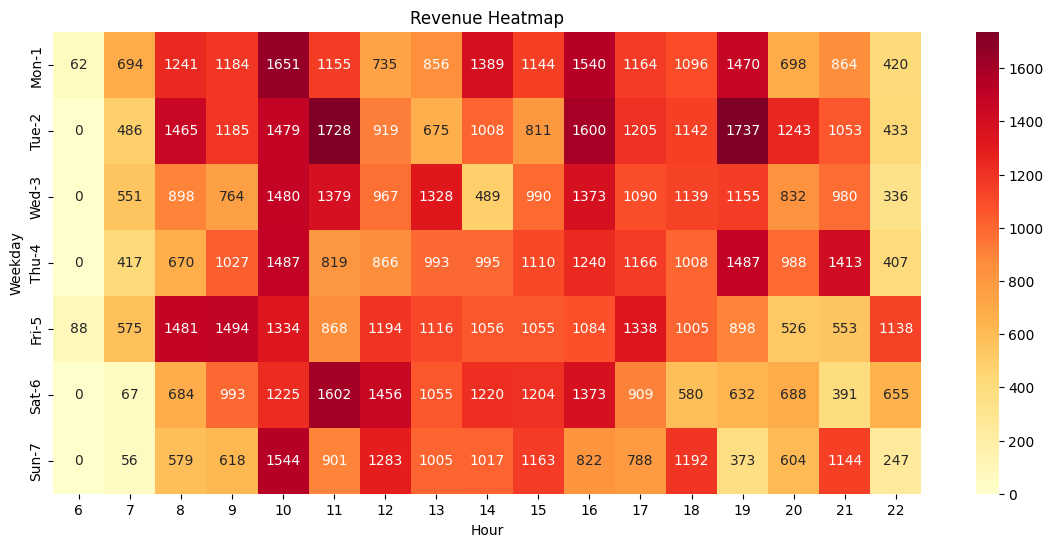

In [228]:
plt.figure(figsize=(14,6))
sns.heatmap(heatmap_data,cmap='YlOrRd',annot=True,fmt='.0f')
plt.title('Revenue Heatmap')
plt.xlabel('Hour')
plt.ylabel('Weekday')
plt.show()

In [229]:
# Find Highest-Earning Slot
max_value = heatmap_data.max().max()

max_location = heatmap_data.stack().idxmax()

print("Highest Revenue Slot:", max_location)
print("Revenue:", max_value)

Highest Revenue Slot: ('Tue', np.int64(2), np.int64(19))
Revenue: 1737.02


In [231]:
# Find Lowest-Earning Slot
min_value = heatmap_data.min().min()
min_location = heatmap_data.stack().idxmin()

print("Highest Revenue Slot:", min_location)
print("Revenue:", min_value)

Highest Revenue Slot: ('Tue', np.int64(2), np.int64(6))
Revenue: 0.0


# Section 13: 7-Day Rolling Revenue Trend
# Plot a smoothed revenue trend using a 7-day rolling average 

In [232]:
daily_revenue = data.groupby('Date')['money'].sum().reset_index(name = 'revenue')
daily_revenue

,Date,revenue
0,2024-03-01,396.30
1,2024-03-02,188.10
2,2024-03-03,309.10
3,2024-03-04,135.20
4,2024-03-05,338.50
...,...,...
376,2025-03-19,623.56
377,2025-03-20,597.60
378,2025-03-21,636.80
379,2025-03-22,365.42


In [233]:
daily_revenue['rolling7'] = daily_revenue['revenue'].rolling(window=7).mean()
daily_revenue

,Date,revenue,rolling7
0,2024-03-01,396.30,NaN
1,2024-03-02,188.10,NaN
2,2024-03-03,309.10,NaN
3,2024-03-04,135.20,NaN
4,2024-03-05,338.50,NaN
...,...,...,...
376,2025-03-19,623.56,433.440000
377,2025-03-20,597.60,466.608571
378,2025-03-21,636.80,456.882857
379,2025-03-22,365.42,476.825714


/tmp/ipykernel_5151/221738117.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x= 'Date', y='revenue', ci =None, marker = 'D', data=daily_revenue, label='revenue')
/tmp/ipykernel_5151/221738117.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='Date', y = 'rolling7', ci = None, marker='D', data=daily_revenue, label ='7Day rolling avg')


<Axes: title={'center': 'daily revenue and 7 day rolling'}, xlabel='Date', ylabel='revenue'>

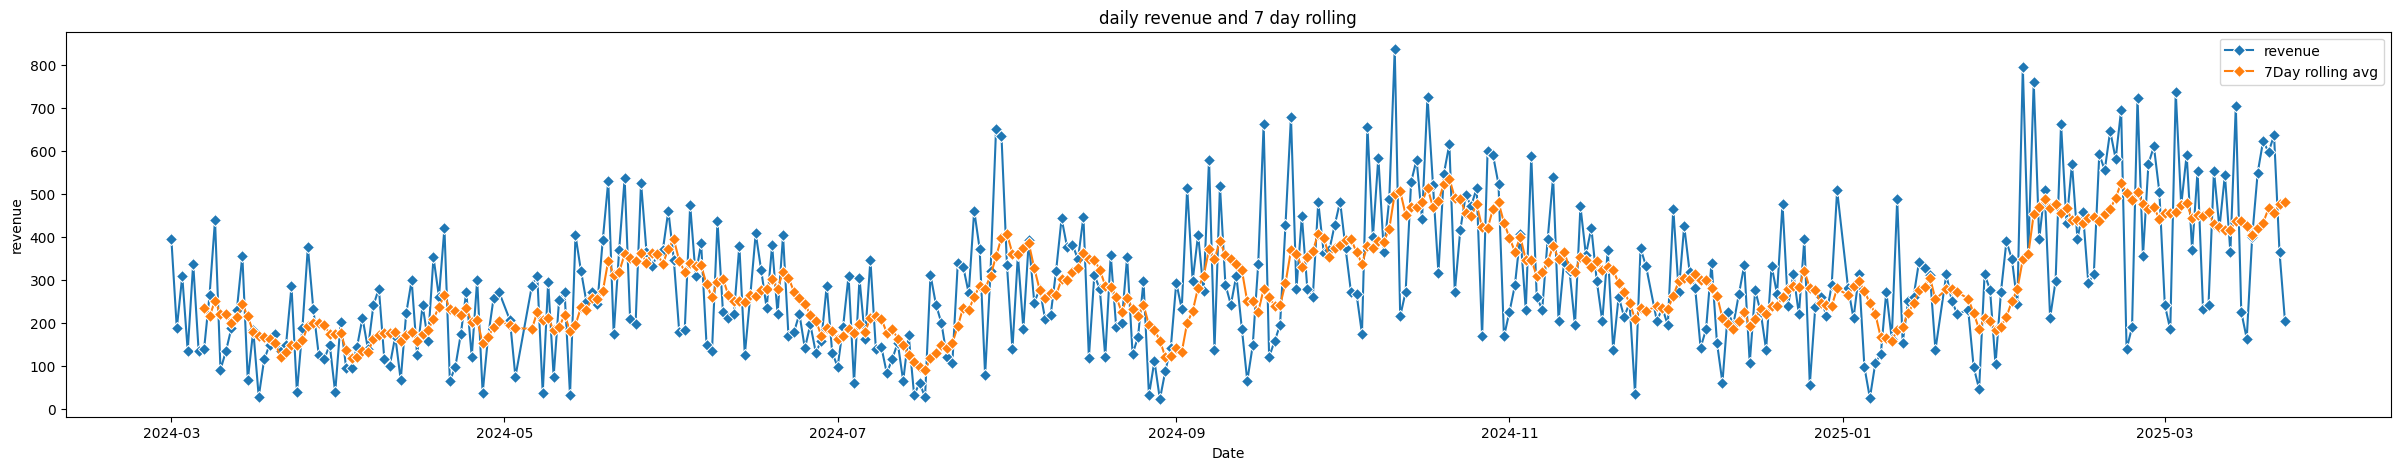

In [237]:
plt.figure(figsize = (30, 5))
plt.title('daily revenue and 7 day rolling')
sns.lineplot(x= 'Date', y='revenue', ci =None, marker = 'D', data=daily_revenue, label='revenue')
sns.lineplot(x='Date', y = 'rolling7', ci = None, marker='D', data=daily_revenue, label ='7Day rolling avg')

# Section 14 Closed days& Business Continuity
# Find the days the shop was closed and why

In [239]:
start_date = data['Date'].min()
end_date = data['Date'].max()
print(start_date)
print(end_date)

2024-03-01 00:00:00
2025-03-23 00:00:00


In [240]:
full_date = pd.date_range(start = start_date, end = end_date)
full_date

DatetimeIndex(['2024-03-01', '2024-03-02', '2024-03-03', '2024-03-04',
               '2024-03-05', '2024-03-06', '2024-03-07', '2024-03-08',
               '2024-03-09', '2024-03-10',
               ...
               '2025-03-14', '2025-03-15', '2025-03-16', '2025-03-17',
               '2025-03-18', '2025-03-19', '2025-03-20', '2025-03-21',
               '2025-03-22', '2025-03-23'],
              dtype='datetime64[ns]', length=388, freq='D')

In [241]:
transaction_date = pd.to_datetime(data['Date'].unique())
transaction_date

<DatetimeArray>
['2024-03-01 00:00:00', '2024-03-02 00:00:00', '2024-03-03 00:00:00',
 '2024-03-04 00:00:00', '2024-03-05 00:00:00', '2024-03-06 00:00:00',
 '2024-03-07 00:00:00', '2024-03-08 00:00:00', '2024-03-09 00:00:00',
 '2024-03-10 00:00:00',
 ...
 '2025-03-14 00:00:00', '2025-03-15 00:00:00', '2025-03-16 00:00:00',
 '2025-03-17 00:00:00', '2025-03-18 00:00:00', '2025-03-19 00:00:00',
 '2025-03-20 00:00:00', '2025-03-21 00:00:00', '2025-03-22 00:00:00',
 '2025-03-23 00:00:00']
Length: 381, dtype: datetime64[ns]

In [244]:
# List of 7 closed dates
missing_dates = full_date.difference(transaction_date)
missing_dates

DatetimeIndex(['2024-05-01', '2024-05-04', '2024-05-05', '2024-11-27',
               '2025-01-01', '2025-01-19', '2025-01-23'],
              dtype='datetime64[ns]', freq=None)

In [246]:
missing_dates = pd.DataFrame({'Closed_Dates': missing_dates})
missing_dates

,Closed_Dates
0,2024-05-01
1,2024-05-04
2,2024-05-05
3,2024-11-27
4,2025-01-01
5,2025-01-19
6,2025-01-23


# Section 15   Opening & Closing Drink Patterns
# What is the first and last drink ordered each day?

In [250]:
OCdrinks = data[['Date', 'hour_of_day']]
OCdrinks

,Date,hour_of_day
0,2024-03-01,10
1,2024-03-01,12
2,2024-03-01,12
3,2024-03-01,13
4,2024-03-01,13
...,...,...
3542,2025-03-23,10
3543,2025-03-23,14
3544,2025-03-23,14
3545,2025-03-23,15


In [254]:
first_order = OCdrinks.groupby('Date').first().reset_index()
first_order

,Date,hour_of_day
0,2024-03-01,10
1,2024-03-02,10
2,2024-03-03,10
3,2024-03-04,10
4,2024-03-05,9
...,...,...
376,2025-03-19,7
377,2025-03-20,8
378,2025-03-21,7
379,2025-03-22,9
